## Imports

In [1]:
from RegionMap import RegionMap
from Fleet import Monitoring_Fleet

import matplotlib.pyplot as plt
import numpy as np
import os 
from datetime import datetime
import pandas as pd

In [2]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## Set up

In [3]:
# Path to load the data

# Amélie
# link = r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# Amélie PC
link = r"E:\datasets\simbarca\all_agg"
df_link = pd.read_csv(r"E:\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# # Orane
# link = r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

In [4]:
def run(link, df_link, File, id = 'pred_vdist', mode = 'random', load = True, pretrained_folder = None):

    
    # Set the parameters
    N_episodes = 26 # 26 
    ep_len     = 5

    buffer_size = 6000
    batch_size = 32

    # --- Create maps --- 

    # Map parameters
    x_size = 20
    y_size = 30


    Map = RegionMap(y_size, x_size, [], [], 1, df_link = df_link, link = link, listFileNumbers=File, load = load)
    Map.initialize_better_importance_map(id)

    # ----- Create a fleet -----
    
    drone_init_pos = [[5,7], [3,26], [10, 3], [10,26]]

    state_shape    = [ep_len, 13]    
    num_stacked = 2    
    alpha = 1e-3

    F = Monitoring_Fleet(Map, buffer_size, state_shape, pretrained_folder, lstm = False, gru = True, num_stacked = num_stacked, alpha = alpha)
    F.add_drones(drone_init_pos) 


    #----- Create save folder paths -----
    
    np.set_printoptions(threshold=np.inf)
    
    current_folder = os.getcwd()
    save_folder = current_folder + "/Results"
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)    
        
    now = datetime.now()
    date_time = now.strftime("%m_%d_%Y_%H_%M_%S")    
    
    current_results = save_folder + "/" + date_time
    if not os.path.exists(current_results):
        os.makedirs(current_results)

   #----- Simultaion -----
    
    t_curr = 0
    
    ep_curr = 0 
    
    T = Map.importance_map.shape[0]-1

    list_of_importance_metric = []
    list_of_patrol_metric     = []
    list_of_reward_metric     = []
    
    while ep_curr < N_episodes:

        print('Episode: ',ep_curr)
        
        ep_step = 0
        
        while ep_step < ep_len:  

            # ------------------------------------------------------------------------------------------
            print('Time | ep_step: ', t_curr, ep_step)

            if t_curr % 10 == 0:
                F.plot_fleets_trajectories(t_curr, T, masked=True)
            
            if t_curr == 0:
            
                list_of_observations, list_of_drone_positions = F.get_fleet_info(t_curr, T)
                list_of_drone_states = F.get_drone_states(list_of_observations, list_of_drone_positions)
                visit_matrix = F.visit_matrix
                
                F.update_drone_state_history(list_of_drone_states)                   
            
        #------------- MOVE -------------------------------------------------------------------------------------
            if mode == 'random':
                list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            elif mode == 'greedy':
                list_of_actions = F.move_drones_greedy(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            elif mode == 'zigzag':
                list_of_actions = F.move
            else:
                if t_curr > ep_len:
                    # function works the same for GRU or LSTM, it is just not the same policy network used
                    list_of_actions = F.move_drones_LSTM(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
                
                else:
                    list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)

            #--------------------------------------------------------------------------------------------------------------------
            
            F.update_drone_action_history(list_of_actions)
            
            list_of_observations_, list_of_drone_positions_ = F.get_fleet_info(t_curr+1, T)
            list_of_drone_states_ = F.get_drone_states(list_of_observations_, list_of_drone_positions_)
            visit_matrix_ = F.visit_matrix
            
            F.update_drone_state_history(list_of_drone_states_)
        
            #----- Reward calculation -----
        
            list_of_rewards = F.get_reward(list_of_observations, list_of_observations_, visit_matrix, visit_matrix_, alpha1=1.0, alpha2=0.5)
            
            print(list_of_rewards)
            
            F.update_drone_reward_history(list_of_rewards)
        
            #----- Collect metrics -----
        
            importance_metric, patrol_metric, reward_metric = F.get_metrics(list_of_rewards)
        
            list_of_importance_metric.append(importance_metric)
            list_of_patrol_metric.append(patrol_metric)
            list_of_reward_metric.append(reward_metric)  
            
            #----- Re-assign states for next iteration -----
        
            list_of_observations    = list_of_observations_
            list_of_drone_positions = list_of_drone_positions_
            list_of_drone_states    = list_of_drone_states_
        
            t_curr  += 1 
            ep_step +=1

        #----- Store transitions in the buffer -----
            
        ep_curr += 1
        
        print("-----------")
    
    F.create_data_set()
    
    F.buffer.save(current_results)

    #----- Save metrics -----
    
    np.save(current_results + "/list_of_importance_metric.npy", np.array(list_of_importance_metric))
    np.save(current_results + "/list_of_patrol_metric.npy"    , np.array(list_of_patrol_metric))
    np.save(current_results + "/list_of_reward_metric.npy"    , np.array(list_of_reward_metric))
    np.save(current_results + "/list_of_perc_visited.npy"     , np.array(F.procentage_visited))

## Run

Episode:  0
Time | ep_step:  0 0


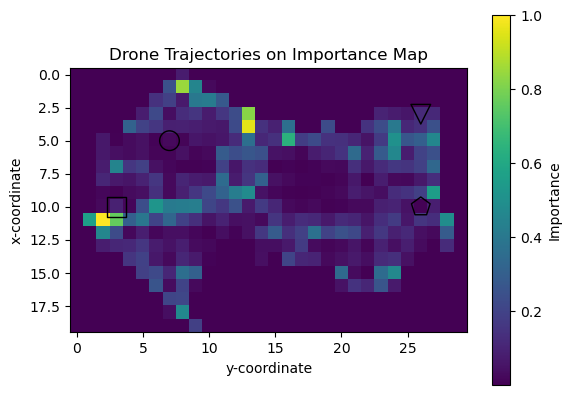

[3.332693861797452, -0.6116009713912263, 8.499181708320975, 2.940102392807603]
Time | ep_step:  1 1
[4.744487646967173, -3.646965966410903, -3.095965066552162, -1.4089075438678267]
Time | ep_step:  2 2
[0.3561816256493333, 0.010761251330711711, -6.2307351440191265, 1.4915096703916793]
Time | ep_step:  3 3
[-6.019171304441986, 4.042842885644434, 2.0400808051228516, -4.387304950039834]
Time | ep_step:  4 4
[0.2912159731984132, -3.850638873140728, 9.710578244179487, 10.315490565652226]
-----------
Episode:  1
Time | ep_step:  5 0
[6.981822793893513, 0.007966418389778532, -0.028921477496623993, -2.619902834761888]
Time | ep_step:  6 1
[-6.511839485183359, 7.717672358250951, 0.4231355581432572, -0.8150787060149023]
Time | ep_step:  7 2
[2.7365602754168212, -0.25175900349997676, -0.890087094157932, 16.81867306780237]
Time | ep_step:  8 3
[7.132456887621434, 4.25, 1.7166401419788624, 0.9857620299335379]
Time | ep_step:  9 4
[4.523459240794182, 4.25, -1.5440632212907102, -0.37324873254704016]


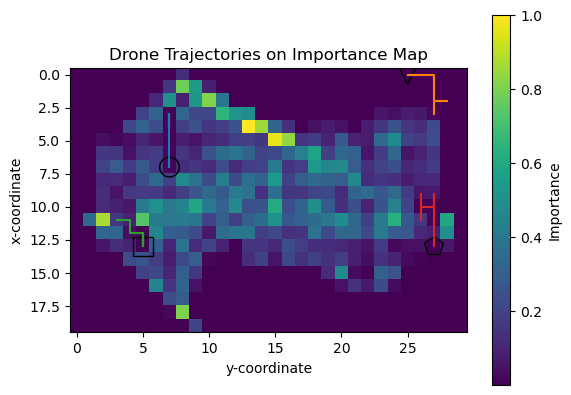

[7.219403157010675, 9.250009999999975, 4.459753711521626, 7.357209360090708]
Time | ep_step:  11 1
[4.900811921805143, 5.039531900157954, 1.0699497498911115, -0.7022001957681423]
Time | ep_step:  12 2
[-9.098254684358837, 6.375348608402306, -2.8340815609660224, 4.163888203145262]
Time | ep_step:  13 3
[2.8500852454453716, 7.328834188936952, -0.27410519016906665, 4.25]
Time | ep_step:  14 4
[5.288520717993378, 5.927844326943159, 9.295733228493479, 4.25]
-----------
Episode:  3
Time | ep_step:  15 0
[7.5553945420682425, -7.584609944373371, -9.337457507181915, 4.25]
Time | ep_step:  16 1
[1.9243950925767428, -2.631671543494706, 9.280948837984358, -0.7500099999999743]
Time | ep_step:  17 2
[21.924916687011724, -0.1094206499874166, -8.85577324773632, 0.8750008749999969]
Time | ep_step:  18 3
[-4.812875859439371, 0.17020405105224026, 8.819963700688444, 0.3749996750000017]
Time | ep_step:  19 4
[2.642311246523832, -0.1806756940924438, 5.958995688447169, 3.4249999913526544e-07]
-----------
Epi

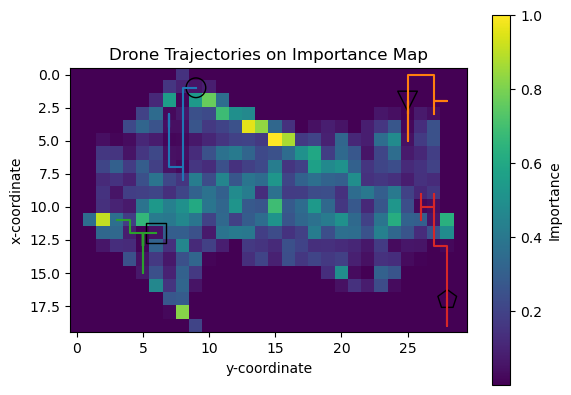

[-6.336210904883387, 0.2749860534203344, -6.440197314131446, 1.0625003750000008]
Time | ep_step:  21 1
[6.2886440484013795, 4.334822864470822, 3.2714882350474617, 1.4912507824999977]
Time | ep_step:  22 2
[7.544692981823092, 7.409946521554145, -3.913230896793304, 1.8946308468261792]
Time | ep_step:  23 3
[-11.711263227976687, 3.3960257148370134, 5.913706253201703, 6.630154568607269]
Time | ep_step:  24 4
[11.405471799291497, 3.7115319948643433, 7.673803826794028, 9.815819882895653]
-----------
Episode:  5
Time | ep_step:  25 0
[-11.378047382757913, 4.4182489328086385, 2.8445455905389267, -3.5171438650989773]
Time | ep_step:  26 1
[5.691006319598203, 7.49859793111682, 5.102996395660398, 4.337365203316863]
Time | ep_step:  27 2
[-3.882687382951173, -2.221491653472186, -5.231499613246655, -1.5020223739387373]
Time | ep_step:  28 3
[9.325947848103766, -0.4030315671116125, -1.3332855496513556, 1.9865682840363974]
Time | ep_step:  29 4
[10.471414131331683, 12.612807771191, -0.093273787572981

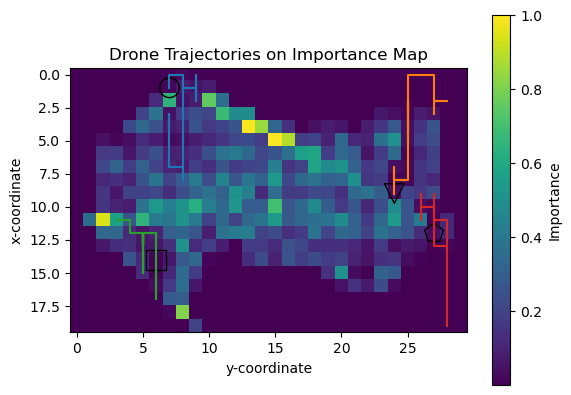

[-0.5333297557341732, 5.561030266806483, 0.7310487029856066, 2.9587342934299605]
Time | ep_step:  31 1
[7.18320891042799, 2.940228059887887, 9.747223944777252, 3.4217366358034718]
Time | ep_step:  32 2
[-0.5725629752069683, 1.5956229642033581, 15.903728117814103, 4.435614422212178]
Time | ep_step:  33 3
[-0.17333749487251526, -4.36084557324648, -0.5399510636925697, 4.35000045]
Time | ep_step:  34 4
[-4.118153792803735, -0.9718899413943283, 1.301449321210384, 4.258750267499999]
-----------
Episode:  7
Time | ep_step:  35 0
[-0.5658236923074158, 0.33787915334105634, 3.1552265770733365, 4.5537508575]
Time | ep_step:  36 1
[-0.2546165426524552, 0.07394668303430052, -6.290077570825816, -0.18750862499997867]
Time | ep_step:  37 2
[-3.121391644025705, -0.25760645367205015, 5.788329100236297, 0.3125]
Time | ep_step:  38 3
[3.174484588394426, 0.7573284191638208, 4.3526311423629584, 0.0712493175000022]
Time | ep_step:  39 4
[-3.556183338527287, -3.1345439064502716, 2.117857299745081, 1.053750832

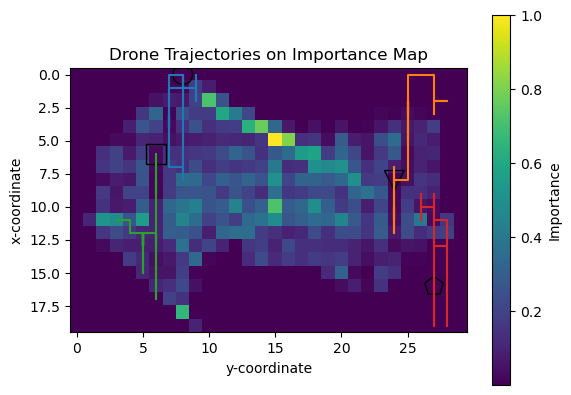

[6.5261527829919554, 4.227528198994695, -4.689237369224429, -1.0537517399999956]
Time | ep_step:  41 1
[3.6705819063570755, 3.650978535600005, 3.1571469362825155, 1.0537524299999939]
Time | ep_step:  42 2
[14.889993322688152, 5.952962931729857, 3.5609774654731154, 1.503750832499997]
Time | ep_step:  43 3
[-16.170464635215783, 8.583338649198414, 4.463770392686874, 1.6574977092844305]
Time | ep_step:  44 4
[15.824821240577185, 2.388664225377145, 1.722220504909009, 5.20314191818501]
-----------
Episode:  9
Time | ep_step:  45 0
[1.2208310556799196, -3.415124393440785, 3.5617452329065893, 6.502091831765206]
Time | ep_step:  46 1
[1.5769483875483266, 3.5613753752782973, 2.3175544807145574, 2.517970102196345]
Time | ep_step:  47 2
[-3.366963609308004, 3.9187421053647986, -0.014536827453842799, 1.909818604206861]
Time | ep_step:  48 3
[16.82035600505769, -3.2662121381610634, 6.250004249999989, -1.8035100972069507]
Time | ep_step:  49 4
[-8.80095462240279, 5.1117311236262335, -6.00001287499996

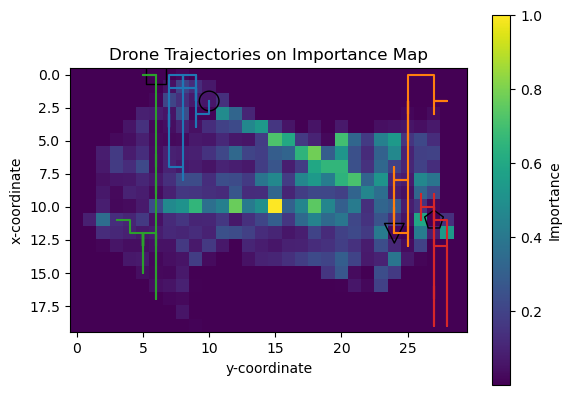

[3.4291103812109918, 3.7747458732873183, 5.750011124999972, 1.141893114404056]
Time | ep_step:  51 1
[-2.5819783755272963, 4.621256098151208, 5.812503124999992, 8.48889739231199]
Time | ep_step:  52 2
[-0.9916022153034404, 3.0274463657226534, 5.942728899593263, 4.0642831276394435]
Time | ep_step:  53 3
[4.152106476454454, 3.198658300363491, 5.873107001425866, -6.336666213296355]
Time | ep_step:  54 4
[3.206729550515588, 3.4545514230171936, 3.6237802080852073, 7.689926525525747]
-----------
Episode:  11
Time | ep_step:  55 0
[0.8172750967960057, 4.245127846992773, 3.7850587796419872, 2.668491255491973]
Time | ep_step:  56 1
[6.974853246212007, 4.25, 4.381899854168296, 3.1473999433219424]
Time | ep_step:  57 2
[3.5696127779781817, -0.7500099999999743, 4.841028404422104, 4.507276218384505]
Time | ep_step:  58 3
[5.375805199705064, 0.8750008749999969, 4.3864786671474585, 0.3080093655735261]
Time | ep_step:  59 4
[3.781160409096629, 0.3749996750000017, 3.908490859903396, 3.0445184711536517]

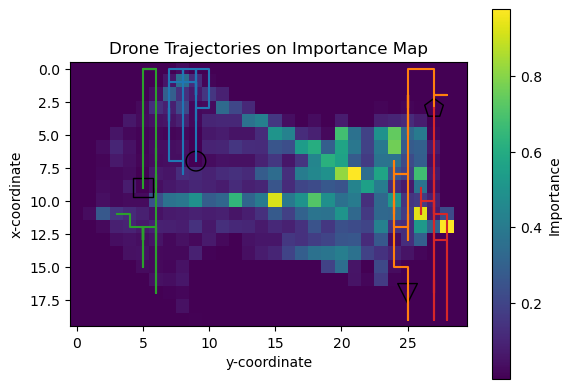

[5.696810310240835, 1.11501206162095, 7.578461261466147, 4.139643890000912]
Time | ep_step:  61 1
[7.794134295545518, 1.9686747649537168, -8.067150295246394, 4.220128971317109]
Time | ep_step:  62 2
[2.250624021515251, 3.427875563306622, 6.986207017209384, -0.7500099999999743]
Time | ep_step:  63 3
[0.898703118786216, 3.6707540622777723, -6.4567246768157975, 4.25]
Time | ep_step:  64 4
[3.9175376929342756, 6.251327363550665, 5.442206685536077, 5.125001749999996]
-----------
Episode:  13
Time | ep_step:  65 0
[5.0537312906235465, 7.067317909896377, -5.59497314102715, 4.3923596601958375]
Time | ep_step:  66 1
[2.483472105970805, -1.5179274901002626, 5.8602069727913495, 5.4206767705463506]
Time | ep_step:  67 2
[4.628946847507564, 2.5770875418372485, -5.948990783373826, 9.198421251416649]
Time | ep_step:  68 3
[4.0768865141818935, 10.697375930882993, 5.999779515904375, 7.171310346253449]
Time | ep_step:  69 4
[3.981196716546123, 1.0120695518888478, -5.255899390127695, 3.4381167162209767]


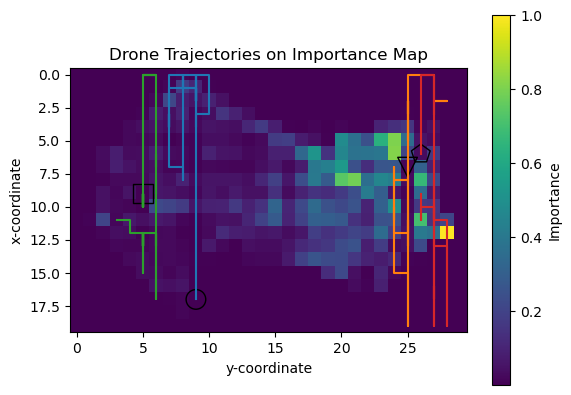

[4.21323661186878, 9.47555586785078, 4.974314815286266, 6.416244514286518]
Time | ep_step:  71 1
[-0.8642138425014987, -0.28039319813251473, -4.85637353235112, 3.5880986413359652]
Time | ep_step:  72 2
[4.250042516449043, -1.7582986429333691, -0.12667977439855746, -2.357463637759707]
Time | ep_step:  73 3
[5.123620726960212, 4.4814086239784965, 5.322273167301912, 8.73338590947166]
Time | ep_step:  74 4
[4.3750005, -6.048148209694773, -5.145551165380052, -0.5700404771182666]
-----------
Episode:  15
Time | ep_step:  75 0
[4.381713879311832, 4.349466347987346, 4.365373989777843, 17.230979280651553]
Time | ep_step:  76 1
[4.388840625346831, 4.197579468549719, 3.1105277862146314, -2.4740452347754616]
Time | ep_step:  77 2
[4.642472646289747, -0.00038057186844184633, 4.1534441231088595, -4.337957262497408]
Time | ep_step:  78 3
[4.349442618228038, 4.239271104147835, 4.1621909057721505, -1.4578042756448997]
Time | ep_step:  79 4
[4.744790888740681, -0.1750085999999779, 3.5937108108012126, 3.

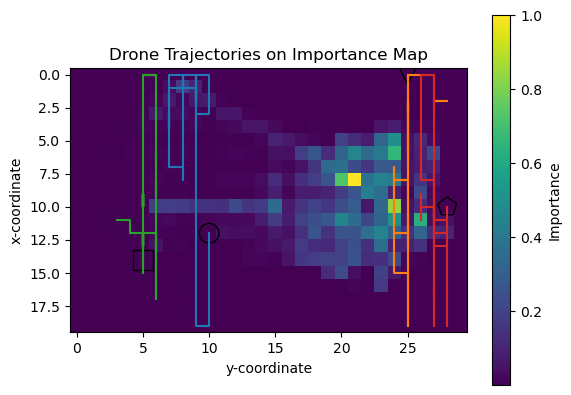

[6.035391116281974, 6.625004999999987, 4.201598522897144, -3.0808662678446677]
Time | ep_step:  81 1
[4.916120000649244, 5.125001749999996, 4.254426712257555, 4.645912658232252]
Time | ep_step:  82 2
[2.1971767997602, 3.9249996000000005, 4.239778591758096, 6.389507094621405]
Time | ep_step:  83 3
[-3.9575387447839594, -5.372345690953493, 4.25, -0.6169221831118933]
Time | ep_step:  84 4
[3.3810817988123754, 4.831563444405181, -0.7500099999999743, 4.25]
-----------
Episode:  17
Time | ep_step:  85 0
[4.792690191898145, 2.4321798622606985, 0.8750008749999969, 4.25]
Time | ep_step:  86 1
[4.67949871756295, 5.612061010458273, 0.3749996750000017, 4.25]
Time | ep_step:  87 2
[4.412375043106891, -6.042278442355887, 1.062500599999998, 4.25]
Time | ep_step:  88 3
[4.4238811145332875, -0.6289896164215616, 1.2875006, 4.25]
Time | ep_step:  89 4
[4.277207920086221, -1.955950173893188, 1.5434818394732486, -4.125009124999978]
-----------
Episode:  18
Time | ep_step:  90 0


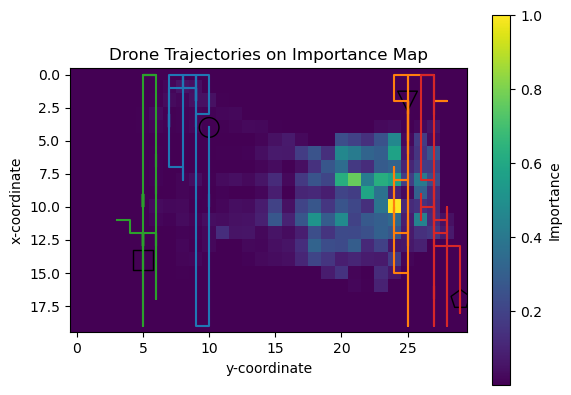

[-0.020470264466712282, 5.697509919999972, 1.766916307124582, 4.000007374999982]
Time | ep_step:  91 1
[-4.102810470500446, 7.930757611499981, -0.06039678409783421, 1.3749999965284435e-07]
Time | ep_step:  92 2
[4.130254101272623, 4.8376593964589825, 2.074751700355049, -3.7500078124999803]
Time | ep_step:  93 3
[4.483524095452157, 9.142461140491037, 1.9775129782787704, 1.2437507374999983]
Time | ep_step:  94 4
[0.4657194585853722, -9.216594917693314, 8.590387624554346, -1.2437522687499944]
-----------
Episode:  19
Time | ep_step:  95 0
[4.5401353247779666, 8.457867862860724, 1.0534704592331157, 1.2437525374999938]
Time | ep_step:  96 1
[4.1664583896676275, 12.80447976447512, 4.063026481948442, 1.734375818749998]
Time | ep_step:  97 2
[-0.8750278562656599, 4.854228256735949, 6.13827268807544, 1.9750008499999991]
Time | ep_step:  98 3
[4.322855143368571, -11.313724296167491, 4.236686195072253, 2.0750005999999988]
Time | ep_step:  99 4
[4.195117373641779, -5.881872495260238, 4.27986574351

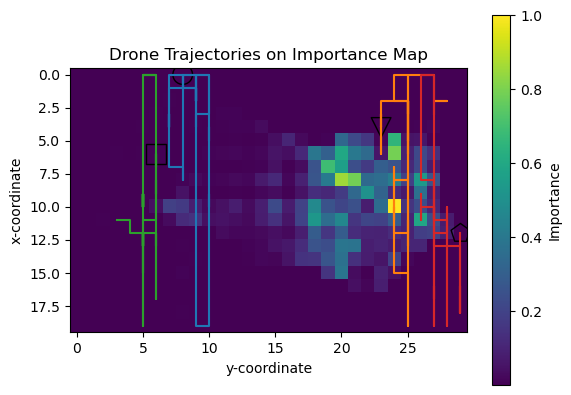

[-4.144661286357704, 0.6908803421490177, 4.194651625935421, 6.3308295898009]
Time | ep_step:  101 1
[9.375010499999977, 9.81480487174944, 4.241555125784686, 3.7461309242679244]
Time | ep_step:  102 2
[4.8125013749999965, -10.40527321425585, 4.274619299187293, 3.4676903588820895]
Time | ep_step:  103 3
[3.9338146107364986, 5.594226314927491, 4.227771976296823, 4.53706061881136]
Time | ep_step:  104 4
[4.586880630980085, 6.256013120842515, 4.368858966994367, 7.01153083630804]
-----------
Episode:  21
Time | ep_step:  105 0
[4.5542974082834355, 4.223216886166483, 4.372317772269156, 1.4471094906330073]
Time | ep_step:  106 1
[-0.700002224999995, 5.598855946213006, -3.9999999899009573e-07, -0.0389420780652984]
Time | ep_step:  107 2
[8.375008749999978, 4.138300456106663, 0.7499932500000177, 6.143361288648607]
Time | ep_step:  108 3
[8.205453131272012, 9.065295740962029, -0.7500010649999969, 1.9283090058412766]
Time | ep_step:  109 4
[4.562600577593258, 2.970496899448336, 0.37800196880512066

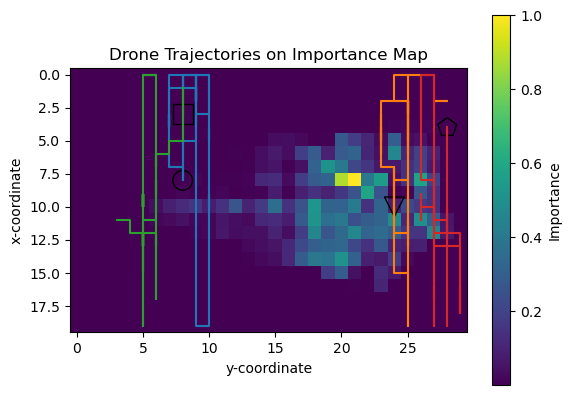

[4.190569095049995, 4.0150591628626, 0.1929275344495308, 4.082481571862672]
Time | ep_step:  111 1
[5.753072192135733, 2.0159977674484253, -2.72419306783678, 4.25]
Time | ep_step:  112 2
[2.8371994304470727, 2.4569558650255208, 4.373299953111214, 4.25]
Time | ep_step:  113 3
[3.9062376812363486, -1.0193071141839027, 3.583300076071114, -0.7500099999999743]
Time | ep_step:  114 4
[4.234685756198388, 4.162436487932155, 0.7213157258299606, -0.7500099999999743]
-----------
Episode:  23
Time | ep_step:  115 0
[-0.9277410546834784, 3.807096849886534, 0.6536595555888441, 0.875000874999998]
Time | ep_step:  116 1
[0.8622149308866935, 3.076877129818769, 1.0216794499142923, 8.250008249999981]
Time | ep_step:  117 2
[8.163341000167733, 4.25, -3.7644122498109924, 5.812503124999992]
Time | ep_step:  118 3
[4.6873753346962275, -0.7500099999999743, 3.79540769399463, 4.375000499999999]
Time | ep_step:  119 4
[4.25, 0.8750008749999969, 4.955270524883056, 4.438829966311062]
-----------
Episode:  24
Time 

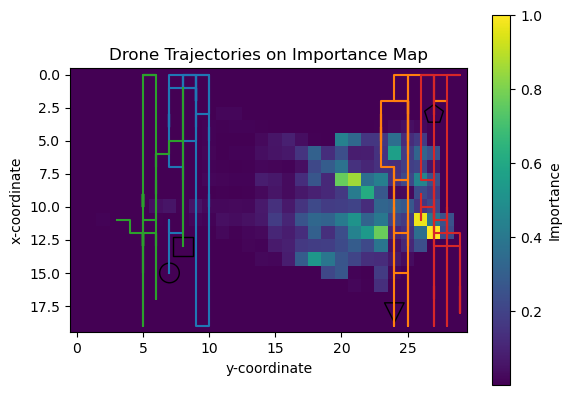

[3.3874982750000076, 0.3749996750000017, 8.859335364755918, -2.313836391311045]
Time | ep_step:  121 1
[4.35000045, 2.9170464668766325, 4.165673935244058, -0.25000267499999346]
Time | ep_step:  122 2
[4.35000045, -0.3337777489770796, -3.8750162499999585, 4.574999988449218e-07]
Time | ep_step:  123 3
[4.350000449999997, 1.5740162190606122, 8.125008249999981, 0.2500005075000001]
Time | ep_step:  124 4
[-0.6875096249999788, 1.0911526322990104, 8.15347719818564, 6.295512826214059]
-----------
Episode:  25
Time | ep_step:  125 0
[0.8750008749999969, 2.8415708199143417, 4.308348045103145, 2.5704914470371993]
Time | ep_step:  126 1
[0.3749996750000017, 3.758194629475477, 4.163182756711194, 5.529798551162196]
Time | ep_step:  127 2
[4.187500125, 7.047115109488368, -6.499999983589098e-07, -1.9282978894134666]
Time | ep_step:  128 3
[-0.6000094499999766, 0.6586600720882418, 3.624989750000027, 0.09999170000002104]
Time | ep_step:  129 4
[0.4199922750000193, -1.733006296929669, 1.1249931850000177,

In [5]:
# Set mode: random, greedy, lstm, nn
mode = 'gru'

pretrained_folder = r'\GRU_13_2_10000iter REAL all files.pth' # r'\GRU_128_3_10000iter.pth'

run(link, df_link, ['000'], id = 'pred_vdist', mode = mode, load = True, pretrained_folder=pretrained_folder)

In [6]:
list_of_perc_gru_1 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_12_2025_22_16_03\list_of_perc_visited.npy')
list_reward_gru_1 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_12_2025_22_16_03\list_of_reward_metric.npy')
list_patrol_gru_1 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_12_2025_22_16_03\list_of_patrol_metric.npy')

In [7]:
list_of_perc_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_23_46_46\list_of_perc_visited.npy')
list_reward_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_reward_metric.npy')
list_patrol_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_patrol_metric.npy')

# list_of_perc_gru_2 = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_perc_visited.npy')
# list_reward_gru_2 = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_reward_metric.npy')
# list_patrol_gru_2 = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_patrol_metric.npy')

In [8]:
list_of_perc_greedy = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_perc_visited.npy')
list_reward_greedy = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_reward_metric.npy')
list_patrol_greedy = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_patrol_metric.npy')

# list_of_perc_greedy = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_perc_visited.npy')
# list_reward_greedy = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_reward_metric.npy')
# list_patrol_greedy = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_patrol_metric.npy')

In [9]:
list_of_perc_random = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_perc_visited.npy')
list_reward_random = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_reward_metric.npy')
list_patrol_random = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_patrol_metric.npy')

# list_of_perc_random = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_perc_visited.npy')
# list_reward_random = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_reward_metric.npy')
# list_patrol_random = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_patrol_metric.npy')

In [10]:
def percentage_above(graphe1, graphe2):

    graphe1 = np.array(graphe1)
    graphe2 = np.array(graphe2)

    if len(graphe1) != len(graphe2):
        raise ValueError("Les deux graphes doivent avoir la même longueur.")

    nb_au_dessus = np.sum(graphe1 > graphe2)
    pourcentage = (nb_au_dessus / len(graphe1)) * 100

    print(f"GRU est au-dessus de LSTM dans {pourcentage:.2f}% des cas.")
    return pourcentage

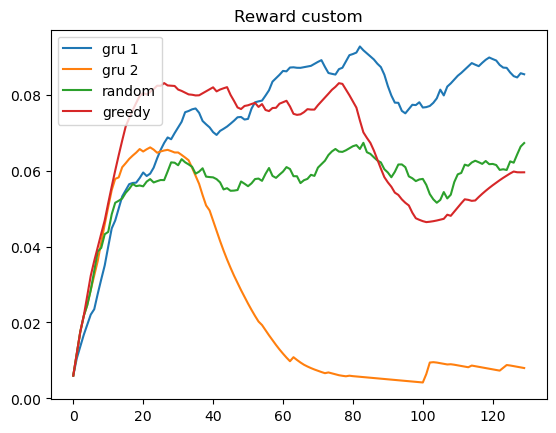

In [11]:
plt.plot(list_patrol_gru_1, label = 'gru 1') # all pickle files
plt.plot(list_patrol_gru_2, label = 'gru 2') # added drones
plt.plot(list_patrol_random, label = 'random')
plt.plot(list_patrol_greedy, label = 'greedy')
plt.title('Reward custom')
plt.legend()

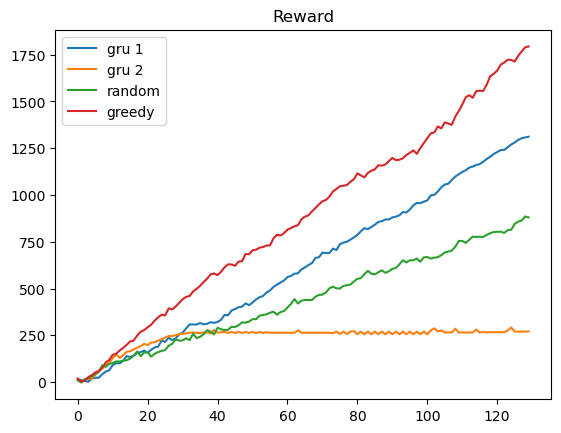

In [12]:
plt.plot(list_reward_gru_1, label = 'gru 1')
plt.plot(list_reward_gru_2, label = 'gru 2')
plt.plot(list_reward_random, label = 'random')
plt.plot(list_reward_greedy, label = 'greedy')
plt.title('Reward')
plt.legend()

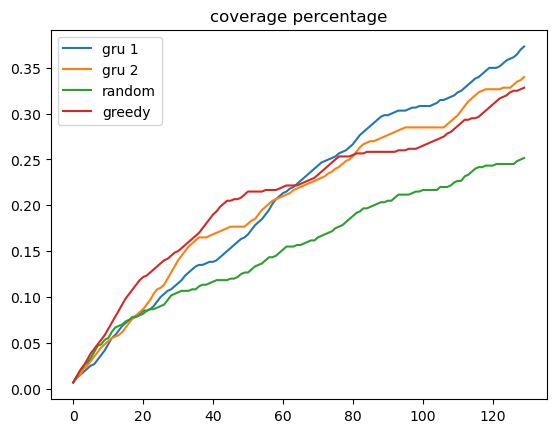

In [13]:
plt.plot(list_of_perc_gru_1, label = 'gru 1')
plt.plot(list_of_perc_gru_2, label = 'gru 2')
plt.plot(list_of_perc_random, label = 'random')
plt.plot(list_of_perc_greedy, label = 'greedy')
plt.title('coverage percentage')
plt.legend()